## TRABAJO PRÁCTICO 1

### PARTE 1 - WHITE PATCH

Se utiliza la función a continuación que permite el balance de blancos de forma automática:
$$ (R, G, B) \longrightarrow \left(\frac{255}{R_{max}(I)}, \frac{255}{G_{max}(I)}, \frac{255}{B_{max}(I)} \right) $$

A partir de esta, proponemos el siguiente script con la función `white_patch(img)` que permitirá procesar las imagenes dentro de la carpeta **white_patch**:

Rmax, Gmax, Bmax
165 138 200
210 250 171
247 157 175
255 255 255
126 252 155
170 255 172
255 134 122
255 201 203


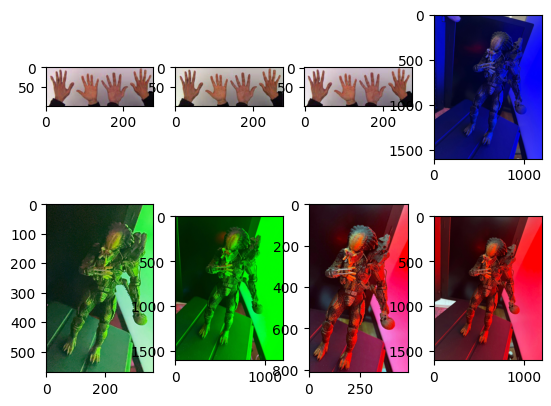

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

# Función que ejecuta el algoritmo de white_patch
def white_patch(img):
    r_max = np.max(img[:,:,0])
    g_max = np.max(img[:,:,1])
    b_max = np.max(img[:,:,2])
    print(r_max, g_max, b_max) # La imagen 4 tiene 255 en RGB máx, devuelve la misma imagen
    img[:,:,0] = cv2.multiply(img[:,:,0], 255/r_max)
    img[:,:,1] = cv2.multiply(img[:,:,1], 255/g_max)
    img[:,:,2] = cv2.multiply(img[:,:,2], 255/b_max)
    return img

# Lectura de las imagenes
paths = os.listdir("white_patch")
images = []
print("Rmax, Gmax, Bmax")
for path in paths:
    img = cv2.imread("white_patch/" + path)
    img_RGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images.append(img_RGB)

# Muestro resultados
fig, ax = plt.subplots(2, 4)
for i in range(len(images)):
    ax[int(i/4), i % 4].imshow(white_patch(images[i]))

plt.show()

Como se observa en los resultados de los RGB máximos para cada imagen, vemos que en el caso de la imagen 4 (primera fila, cuarta columna), los valores máximos son 255 para los 3 casos, por lo que devuelve la misma imagen y no se aplica ninguna corrección. Esto es una de las fallas que presenta este método, por lo que generalmente se toma un porcentaje del valor máximo (98-99%) para evitar este problema.

### PARTE 2 - HISTOGRAMA

Para realizar los histogramas se utiliza la función `hist()` provista por matpltolib, con un número de bins igual a 256 para ambos casos, ya que nuestro espacio de color tiene 256 valores posibles. En el siguiente script se puede ver esto:

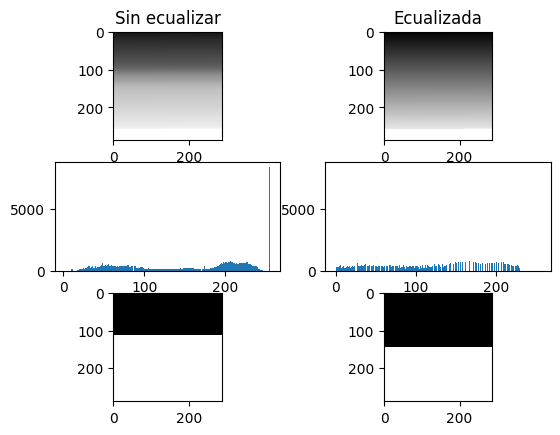

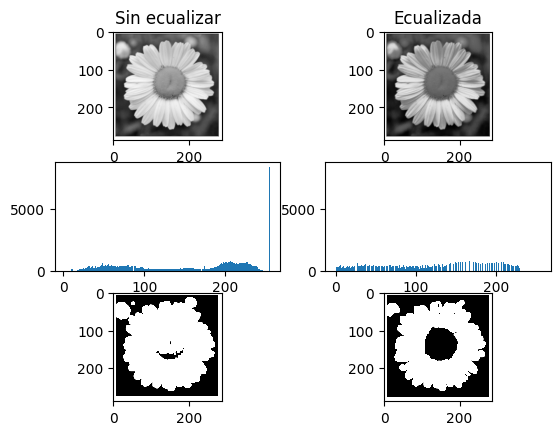

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Leo imagenes en escala de grises
img_1 = cv2.imread("img1_tp.png", cv2.IMREAD_GRAYSCALE)
img_2 = cv2.imread("img2_tp.png", cv2.IMREAD_GRAYSCALE)

# IMAGEN 1 - GRADIENTE
fig, ax = plt.subplots(3, 2)
ax[0, 0].set_title("Sin ecualizar")
ax[0, 0].imshow(img_1, cmap="gray")

bins_1 = 256
ax[1, 0].hist(img_1.ravel(), bins_1)
ret, thresh = cv2.threshold(img_1, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
ax[2, 0].imshow(thresh, cmap='gray', vmin=0, vmax=1)

img_1_eq = cv2.equalizeHist(img_1)
ax[0, 1].set_title("Ecualizada")
ax[0, 1].imshow(img_1_eq, cmap="gray")
ax[1, 1].hist(img_1_eq.ravel(), bins_1)
ret, thresh = cv2.threshold(img_1_eq, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
ax[2, 1].imshow(thresh, cmap='gray', vmin=0, vmax=1)

plt.show()

# IMAGEN 2 - FLOR
fig, ax = plt.subplots(3, 2)
ax[0, 0].set_title("Sin ecualizar")
ax[0, 0].imshow(img_2, cmap="gray")

bins_2 = 256
ax[1, 0].hist(img_2.ravel(), bins_2)
ret, thresh = cv2.threshold(img_2, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
ax[2, 0].imshow(thresh, cmap='gray', vmin=0, vmax=1)

img_2_eq = cv2.equalizeHist(img_2)
ax[0, 1].set_title("Ecualizada")
ax[0, 1].imshow(img_2_eq, cmap="gray")
ax[1, 1].hist(img_2_eq.ravel(), bins_2)
ret, thresh = cv2.threshold(img_2_eq, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
ax[2, 1].imshow(thresh, cmap='gray', vmin=0, vmax=1)

plt.show()


Podemos ver que para ambas imagenes el histograma resultante es muy similar, teniendo dos máximos locales (excluyendo el de 255) cercanos a 50 y 200. Esto nos indica que dos imágenes muy distintas, un gradiente y una flor en nuestro caso, pueden tener histogramas parecidos. Esto implica que el uso de histogramas como método de comparación para entrenar un modelo para la detección de imágenes podría arrojar resultados erróneos ya que estos no contienen información sobre la ubicación de los pixeles, únicamente tienen en cuenta la intensidad. A pesar de ello, si son una herramienta útil de pre-procesamiento para llevar la imagen a las características deseadas. Un ejemplo de esto son las ecualizaciones donde buscamos ampliar el rango dinámico y mejorar el contraste de la imagen. De esta manera, luego se podrá aplicar un algoritmo de binarización, como el de OTSU, donde veremos que se logra un mejor trabajo al distinguir los pétalos de la flor del resto de la imagen.